## 04 Threshold Evaluation

This notebook converts similarity scores into binary overlap decisions for the shortlisted model, text-variant, and similarity-metric configurations selected in Notebook 03.

### Main goal

The purpose of Notebook 04 is to evaluate **decision quality**.

It answers:

> Which embedding model and similarity threshold combination optimally balances precision and recall for curriculum overlap detection?

### What this notebook does

- loads the long-format pair similarity scores from Notebook 03
- loads the shortlist of configurations selected for threshold evaluation
- evaluates threshold behavior on the **development split**
- identifies candidate thresholds for each configuration using explicit threshold-selection strategies
- compares threshold strategies such as:
  - maximum F1
  - maximum F0.5
  - precision-floor threshold
  - reviewer-load threshold
- prepares one locked threshold per shortlisted configuration for later held-out test evaluation

### What this notebook does not do yet

- it does not re-embed courses
- it does not re-rank models from scratch
- it does not use the test set for threshold selection
- it does not claim the final winner before held-out evaluation is completed

### Important methodological note

Thresholds are selected using the **development split only**.

The **test split must remain locked** until threshold selection is complete. This is necessary to preserve a meaningful held-out evaluation.

### Evaluation context from Notebook 03

The shortlisted configurations come from a course-level split with:

- development pairs: 595
- development positives: 20
- test pairs: 105
- test positives: 5

Because the test set still contains only a small number of positive pairs, final test metrics must be interpreted cautiously.

In [1]:
# Cell 01 - Import libraries and define project paths

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "thresholds"
TABLES_DIR = REPORTS_DIR / "tables" / "thresholds"
BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
BENCHMARK_TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"

PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
SHORTLIST_CSV_PATH = BENCHMARK_TABLES_DIR / "shortlist_for_notebook_04.csv"

THRESHOLD_SCAN_CSV_PATH = TABLES_DIR / "threshold_scan_dev.csv"
CANDIDATE_THRESHOLDS_CSV_PATH = TABLES_DIR / "candidate_thresholds_dev.csv"
SELECTED_THRESHOLDS_CSV_PATH = TABLES_DIR / "selected_thresholds_for_test.csv"
DEV_THRESHOLD_SUMMARY_CSV_PATH = TABLES_DIR / "dev_threshold_summary.csv"
TEST_EVALUATION_CSV_PATH = TABLES_DIR / "test_evaluation_locked_thresholds.csv"
DEV_TEST_COMPARISON_CSV_PATH = TABLES_DIR / "dev_test_threshold_comparison.csv"
PRACTICAL_INTERPRETATION_CSV_PATH = TABLES_DIR / "practical_threshold_interpretation.csv"

for path in [FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Pair scores CSV:", PAIR_SCORES_CSV_PATH)
print("Pair scores Parquet:", PAIR_SCORES_PARQUET_PATH)
print("Shortlist CSV:", SHORTLIST_CSV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Pair scores CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Pair scores Parquet: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.parquet
Shortlist CSV: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\thresholds
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds


### Load benchmark outputs

This notebook uses:

- the long-format similarity score table from Notebook 03
- the shortlisted configurations selected for threshold evaluation

In [2]:
# Cell 02 - Load benchmark outputs

if PAIR_SCORES_PARQUET_PATH.exists():
    pair_scores_long_df = pd.read_parquet(PAIR_SCORES_PARQUET_PATH)
else:
    pair_scores_long_df = pd.read_csv(PAIR_SCORES_CSV_PATH, encoding="utf-8")

shortlist_df = pd.read_csv(SHORTLIST_CSV_PATH, encoding="utf-8")

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("shortlist_df shape:", shortlist_df.shape)

display(pair_scores_long_df.head(3))
display(shortlist_df.head(10))

pair_scores_long_df shape: (14000, 13)
shortlist_df shape: (6, 18)


,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,split,model_name,text_variant,similarity_metric,similarity_score,embedding_dim,encoding_seconds
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,TT00CD71,Linux Basics,0,test,tfidf,main,cosine,0.250348,4534,0.063107
1,TT00CD70__TT00CD76,TT00CD70,Data Networks,TT00CD76,Scripting and Automatization,0,test,tfidf,main,cosine,0.213901,4534,0.063107
2,TT00CD70__TT00CD77,TT00CD70,Data Networks,TT00CD77,Basics of Programming,0,test,tfidf,main,cosine,0.229987,4534,0.063107


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,metric_preference_rank,shortlist_rank
0,openai_text-embedding-3-large,enriched,cosine,595,20,575,0.033613,0.672488,0.455197,0.217292,0.669671,0.440653,0.229018,0.644586,19.176442,0.978261,0,1
1,multilingual-e5-large,enriched,cosine,595,20,575,0.033613,0.936979,0.901361,0.035617,0.934471,0.900470,0.034001,0.625485,18.608173,0.962435,0,2
2,multilingual-e5-large,main,cosine,595,20,575,0.033613,0.926948,0.891084,0.035864,0.927504,0.890032,0.037472,0.584493,17.388679,0.952261,0,3
3,bge-m3,enriched,cosine,595,20,575,0.033613,0.751666,0.622171,0.129496,0.738406,0.617110,0.121296,0.560155,16.664612,0.954522,0,4
4,multilingual-e5-base,enriched,cosine,595,20,575,0.033613,0.932840,0.901833,0.031007,0.933102,0.901464,0.031639,0.503028,14.965086,0.933826,0,5
5,tfidf,enriched,cosine,595,20,575,0.033613,0.284691,0.126054,0.158637,0.251471,0.119261,0.132210,0.479716,14.271547,0.918522,0,6


In [3]:
# Cell 03 - Validate required columns

required_pair_score_columns = [
    "pair_id",
    "overlap_label_binary",
    "split",
    "model_name",
    "text_variant",
    "similarity_metric",
    "similarity_score",
]

required_shortlist_columns = [
    "model_name",
    "text_variant",
    "similarity_metric",
]

missing_pair_score_columns = [col for col in required_pair_score_columns if col not in pair_scores_long_df.columns]
missing_shortlist_columns = [col for col in required_shortlist_columns if col not in shortlist_df.columns]

if missing_pair_score_columns:
    raise ValueError(f"Missing required pair score columns: {missing_pair_score_columns}")

if missing_shortlist_columns:
    raise ValueError(f"Missing required shortlist columns: {missing_shortlist_columns}")

if pair_scores_long_df["split"].isna().any():
    raise ValueError("Found missing split values in pair_scores_long_df.")

print("All required columns are present.")

All required columns are present.


### Filter to shortlisted configurations

Notebook 04 evaluates only the shortlisted configurations from Notebook 03.  
This keeps threshold analysis focused and avoids unnecessary repetition.

In [4]:
# Cell 04 - Filter the long-format score table to shortlisted configurations

shortlist_keys_df = shortlist_df[["model_name", "text_variant", "similarity_metric"]].drop_duplicates().copy()

evaluation_scores_df = pair_scores_long_df.merge(
    shortlist_keys_df,
    on=["model_name", "text_variant", "similarity_metric"],
    how="inner",
)

if evaluation_scores_df.empty:
    raise ValueError("No rows remained after filtering to shortlisted configurations.")

print("evaluation_scores_df shape:", evaluation_scores_df.shape)
display(
    evaluation_scores_df[["model_name", "text_variant", "similarity_metric"]]
    .drop_duplicates()
    .sort_values(["model_name", "text_variant", "similarity_metric"])
    .reset_index(drop=True)
)

evaluation_scores_df shape: (4200, 13)


,model_name,text_variant,similarity_metric
0,bge-m3,enriched,cosine
1,multilingual-e5-base,enriched,cosine
2,multilingual-e5-large,enriched,cosine
3,multilingual-e5-large,main,cosine
4,openai_text-embedding-3-large,enriched,cosine
5,tfidf,enriched,cosine


### Verify split context

Before threshold tuning begins, verify the number of pairs and positives in the development and test splits for the shortlisted configurations.

In [5]:
# Cell 05 - Verify split context

split_context_df = (
    evaluation_scores_df
    .groupby(["model_name", "text_variant", "similarity_metric", "split"])["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
    .reset_index()
    .sort_values(["model_name", "text_variant", "similarity_metric", "split"])
    .reset_index(drop=True)
)

display(split_context_df)

dev_pair_count_check = evaluation_scores_df.loc[evaluation_scores_df["split"] == "dev", "pair_id"].nunique()
dev_positive_count_check = evaluation_scores_df.loc[
    evaluation_scores_df["split"] == "dev"
].drop_duplicates(subset=["pair_id"])["overlap_label_binary"].sum()

test_pair_count_check = evaluation_scores_df.loc[evaluation_scores_df["split"] == "test", "pair_id"].nunique()
test_positive_count_check = evaluation_scores_df.loc[
    evaluation_scores_df["split"] == "test"
].drop_duplicates(subset=["pair_id"])["overlap_label_binary"].sum()

print("Unique dev pairs:", int(dev_pair_count_check))
print("Unique dev positives:", int(dev_positive_count_check))
print("Unique test pairs:", int(test_pair_count_check))
print("Unique test positives:", int(test_positive_count_check))

,model_name,text_variant,similarity_metric,split,count,positive_count
0,bge-m3,enriched,cosine,dev,595,20
1,bge-m3,enriched,cosine,test,105,5
2,multilingual-e5-base,enriched,cosine,dev,595,20
3,multilingual-e5-base,enriched,cosine,test,105,5
4,multilingual-e5-large,enriched,cosine,dev,595,20
5,multilingual-e5-large,enriched,cosine,test,105,5
6,multilingual-e5-large,main,cosine,dev,595,20
7,multilingual-e5-large,main,cosine,test,105,5
8,openai_text-embedding-3-large,enriched,cosine,dev,595,20
9,openai_text-embedding-3-large,enriched,cosine,test,105,5


Unique dev pairs: 595
Unique dev positives: 20
Unique test pairs: 105
Unique test positives: 5


### Threshold evaluation helpers

Threshold scanning is performed on the **development split only**.

For each threshold, the notebook computes:

- precision
- recall
- F1
- F0.5
- accuracy
- specificity
- predicted positive count
- confusion-matrix counts

These metrics support both statistical and practical threshold decisions.

In [6]:
# Cell 06 - Threshold evaluation helper functions

def compute_confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def compute_threshold_metrics(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)

    counts = compute_confusion_counts(y_true, y_pred)

    specificity = counts["tn"] / (counts["tn"] + counts["fp"]) if (counts["tn"] + counts["fp"]) > 0 else np.nan

    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f05": fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "specificity": specificity,
        "predicted_positive_count": int(y_pred.sum()),
        "tn": counts["tn"],
        "fp": counts["fp"],
        "fn": counts["fn"],
        "tp": counts["tp"],
    }

def build_threshold_grid(y_score: np.ndarray, max_points: int = 400) -> np.ndarray:
    """
    Build a threshold grid using the observed score range.

    The grid includes:
    - all unique score values if the number is small enough
    - otherwise a dense linear grid across the observed range
    """
    unique_scores = np.unique(np.round(y_score, 10))

    if len(unique_scores) <= max_points:
        grid = unique_scores
    else:
        grid = np.linspace(y_score.min(), y_score.max(), max_points)

    epsilon = 1e-9
    grid = np.unique(np.concatenate([grid, [y_score.max() + epsilon]]))

    return np.sort(grid)

def slugify_name(text: str) -> str:
    return text.lower().replace("/", "_").replace(" ", "_").replace(":", "_")

### Build threshold scan table on development split

For each shortlisted configuration, scan thresholds across the observed similarity-score range and record decision metrics on the development split.

In [7]:
# Cell 07 - Build threshold scan table on development split

dev_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("Development split is empty after shortlist filtering.")

threshold_scan_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    threshold_grid = build_threshold_grid(y_score=y_score, max_points=400)

    for threshold in threshold_grid:
        metrics = compute_threshold_metrics(y_true=y_true, y_score=y_score, threshold=threshold)

        threshold_scan_rows.append({
            "model_name": model_name,
            "text_variant": text_variant,
            "similarity_metric": similarity_metric,
            "pair_count_dev": len(group_df),
            "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
            **metrics,
        })

threshold_scan_dev_df = pd.DataFrame(threshold_scan_rows)

if threshold_scan_dev_df.empty:
    raise ValueError("threshold_scan_dev_df is empty.")

threshold_scan_dev_df.to_csv(THRESHOLD_SCAN_CSV_PATH, index=False, encoding="utf-8")

print("Saved threshold scan table to:", THRESHOLD_SCAN_CSV_PATH)
print("threshold_scan_dev_df shape:", threshold_scan_dev_df.shape)

display(threshold_scan_dev_df.head(10))

Saved threshold scan table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\threshold_scan_dev.csv
threshold_scan_dev_df shape: (2406, 17)


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,enriched,cosine,595,20,0.495837,0.033613,1.0,0.065041,0.041667,0.033613,0.000000,595,0,575,0,20
1,bge-m3,enriched,cosine,595,20,0.496712,0.033670,1.0,0.065147,0.041736,0.035294,0.001739,594,1,574,0,20
2,bge-m3,enriched,cosine,595,20,0.497588,0.033670,1.0,0.065147,0.041736,0.035294,0.001739,594,1,574,0,20
3,bge-m3,enriched,cosine,595,20,0.498464,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
4,bge-m3,enriched,cosine,595,20,0.499340,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
5,bge-m3,enriched,cosine,595,20,0.500215,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
6,bge-m3,enriched,cosine,595,20,0.501091,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
7,bge-m3,enriched,cosine,595,20,0.501967,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
8,bge-m3,enriched,cosine,595,20,0.502843,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20
9,bge-m3,enriched,cosine,595,20,0.503719,0.033727,1.0,0.065253,0.041806,0.036975,0.003478,593,2,573,0,20


### Inspect threshold scan summary

This summary helps confirm that each shortlisted configuration has a valid threshold scan and gives a first view of score-range differences across model families.

In [8]:
# Cell 08 - Threshold scan summary by configuration

threshold_scan_summary_df = (
    threshold_scan_dev_df
    .groupby(["model_name", "text_variant", "similarity_metric"])
    .agg(
        threshold_count=("threshold", "count"),
        threshold_min=("threshold", "min"),
        threshold_max=("threshold", "max"),
        max_f1=("f1", "max"),
        max_f05=("f05", "max"),
        max_precision=("precision", "max"),
        max_recall=("recall", "max"),
        min_predicted_positive_count=("predicted_positive_count", "min"),
        max_predicted_positive_count=("predicted_positive_count", "max"),
    )
    .reset_index()
    .sort_values(["max_f1", "max_f05", "max_precision"], ascending=[False, False, False])
    .reset_index(drop=True)
)

display(threshold_scan_summary_df)

,model_name,text_variant,similarity_metric,threshold_count,threshold_min,threshold_max,max_f1,max_f05,max_precision,max_recall,min_predicted_positive_count,max_predicted_positive_count
0,openai_text-embedding-3-large,enriched,cosine,401,0.285960,0.778542,0.666667,0.677083,1.0,1.0,0,595
1,multilingual-e5-large,main,cosine,401,0.857573,0.953899,0.580645,0.703125,1.0,1.0,0,595
2,multilingual-e5-large,enriched,cosine,401,0.866033,0.956996,0.577778,0.673077,1.0,1.0,0,595
3,multilingual-e5-base,enriched,cosine,401,0.862447,0.960807,0.511628,0.588235,1.0,1.0,0,595
4,bge-m3,enriched,cosine,401,0.495837,0.845275,0.509091,0.625000,1.0,1.0,0,595
5,tfidf,enriched,cosine,401,0.045829,0.601170,0.476190,0.555556,1.0,1.0,0,595


### Candidate threshold selection on development split

For each configuration, identify several candidate thresholds using explicit rules:

- **max_f1**
- **max_f05** for a more precision-oriented balance
- **precision_floor_080**
- **reviewer_load_target_10**

These are still selected on the development split only.

In [9]:
# Cell 09 - Select candidate thresholds from the development threshold scan

candidate_threshold_rows = []

for (model_name, text_variant, similarity_metric), group_df in threshold_scan_dev_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    working_df = group_df.sort_values("threshold").reset_index(drop=True)

    # A. Max-F1 threshold
    max_f1_row = working_df.sort_values(
        ["f1", "precision", "recall", "threshold"],
        ascending=[False, False, False, True]
    ).iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "max_f1",
        **max_f1_row.to_dict(),
    })

    # B. Max-F0.5 threshold
    max_f05_row = working_df.sort_values(
        ["f05", "precision", "recall", "threshold"],
        ascending=[False, False, False, True]
    ).iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "max_f05",
        **max_f05_row.to_dict(),
    })

    # C. Precision floor threshold
    # Choose the highest-recall threshold among those with precision >= 0.80.
    precision_floor_pool = working_df[working_df["precision"] >= 0.80].copy()

    if precision_floor_pool.empty:
        precision_floor_pool = working_df.copy()

    precision_floor_row = precision_floor_pool.sort_values(
        ["recall", "f1", "precision", "threshold"],
        ascending=[False, False, False, True]
    ).iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "precision_floor_080",
        **precision_floor_row.to_dict(),
    })

    # D. Reviewer-load threshold
    # Choose threshold with predicted positive count closest to 10,
    # preferring higher precision, then higher F1.
    reviewer_target = 10
    reviewer_pool = working_df.copy()
    reviewer_pool["reviewer_load_distance"] = (reviewer_pool["predicted_positive_count"] - reviewer_target).abs()

    reviewer_row = reviewer_pool.sort_values(
        ["reviewer_load_distance", "precision", "f1", "threshold"],
        ascending=[True, False, False, True]
    ).iloc[0]

    candidate_threshold_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": "reviewer_load_target_10",
        **reviewer_row.drop(labels=["reviewer_load_distance"]).to_dict(),
    })

candidate_thresholds_dev_df = pd.DataFrame(candidate_threshold_rows)

candidate_thresholds_dev_df.to_csv(CANDIDATE_THRESHOLDS_CSV_PATH, index=False, encoding="utf-8")

print("Saved candidate thresholds to:", CANDIDATE_THRESHOLDS_CSV_PATH)
display(candidate_thresholds_dev_df)

Saved candidate thresholds to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\candidate_thresholds_dev.csv


,model_name,text_variant,similarity_metric,selection_rule,pair_count_dev,positive_count_dev,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,bge-m3,enriched,cosine,max_f1,595,20,0.721789,0.400000,0.70,0.509091,0.437500,0.954622,0.963478,35,554,21,6,14
1,bge-m3,enriched,cosine,max_f05,595,20,0.782218,0.857143,0.30,0.444444,0.625000,0.974790,0.998261,7,574,1,14,6
2,bge-m3,enriched,cosine,precision_floor_080,595,20,0.782218,0.857143,0.30,0.444444,0.625000,0.974790,0.998261,7,574,1,14,6
3,bge-m3,enriched,cosine,reviewer_load_target_10,595,20,0.777839,0.700000,0.35,0.466667,0.583333,0.973109,0.994783,10,572,3,13,7
4,multilingual-e5-base,enriched,cosine,max_f1,595,20,0.932211,0.478261,0.55,0.511628,0.491071,0.964706,0.979130,23,563,12,9,11
5,multilingual-e5-base,enriched,cosine,max_f05,595,20,0.937141,0.666667,0.40,0.500000,0.588235,0.973109,0.993043,12,571,4,12,8
6,multilingual-e5-base,enriched,cosine,precision_floor_080,595,20,0.946016,1.000000,0.20,0.333333,0.555556,0.973109,1.000000,4,575,0,16,4
7,multilingual-e5-base,enriched,cosine,reviewer_load_target_10,595,20,0.938127,0.600000,0.30,0.400000,0.500000,0.969748,0.993043,10,571,4,14,6
8,multilingual-e5-large,enriched,cosine,max_f1,595,20,0.932374,0.520000,0.65,0.577778,0.541667,0.968067,0.979130,25,563,12,7,13
9,multilingual-e5-large,enriched,cosine,max_f05,595,20,0.946509,0.875000,0.35,0.500000,0.673077,0.976471,0.998261,8,574,1,13,7


In [10]:
# Cell 10 - Compact development threshold summary for review

dev_threshold_summary_df = candidate_thresholds_dev_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

dev_threshold_summary_df = dev_threshold_summary_df.sort_values(
    ["model_name", "text_variant", "similarity_metric", "selection_rule"]
).reset_index(drop=True)

dev_threshold_summary_df.to_csv(DEV_THRESHOLD_SUMMARY_CSV_PATH, index=False, encoding="utf-8")

print("Saved development threshold summary to:", DEV_THRESHOLD_SUMMARY_CSV_PATH)
display(dev_threshold_summary_df)

Saved development threshold summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_threshold_summary.csv


,model_name,text_variant,similarity_metric,selection_rule,threshold,precision,recall,f1,f05,specificity,predicted_positive_count,tp,fp,fn,tn
0,bge-m3,enriched,cosine,max_f05,0.782218,0.857143,0.30,0.444444,0.625000,0.998261,7,6,1,14,574
1,bge-m3,enriched,cosine,max_f1,0.721789,0.400000,0.70,0.509091,0.437500,0.963478,35,14,21,6,554
2,bge-m3,enriched,cosine,precision_floor_080,0.782218,0.857143,0.30,0.444444,0.625000,0.998261,7,6,1,14,574
3,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,0.994783,10,7,3,13,572
4,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,0.993043,12,8,4,12,571
5,multilingual-e5-base,enriched,cosine,max_f1,0.932211,0.478261,0.55,0.511628,0.491071,0.979130,23,11,12,9,563
6,multilingual-e5-base,enriched,cosine,precision_floor_080,0.946016,1.000000,0.20,0.333333,0.555556,1.000000,4,4,0,16,575
7,multilingual-e5-base,enriched,cosine,reviewer_load_target_10,0.938127,0.600000,0.30,0.400000,0.500000,0.993043,10,6,4,14,571
8,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,0.998261,8,7,1,13,574
9,multilingual-e5-large,enriched,cosine,max_f1,0.932374,0.520000,0.65,0.577778,0.541667,0.979130,25,13,12,7,563


### Threshold behavior plots

These plots are essential for understanding threshold stability.

For each shortlisted configuration, inspect:

- threshold vs precision
- threshold vs recall
- threshold vs F1
- threshold vs F0.5
- threshold vs predicted positive count

This is especially important for compressed-score models such as multilingual E5.

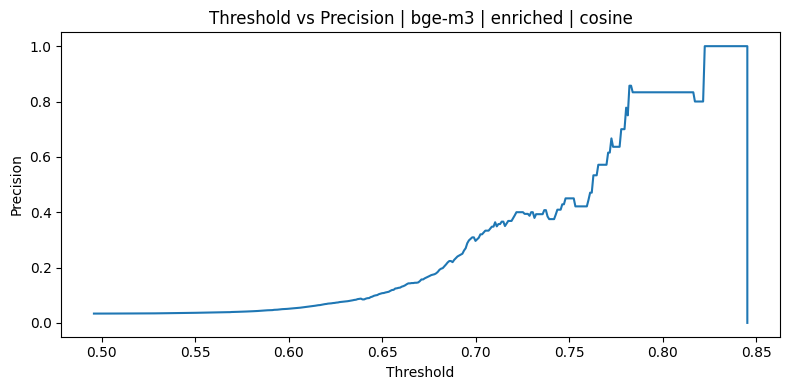

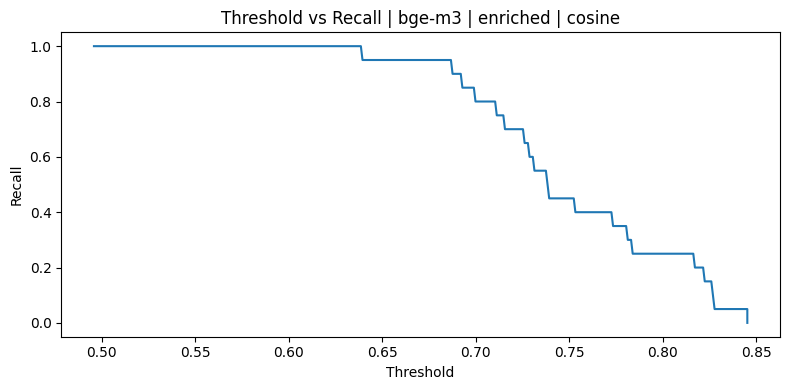

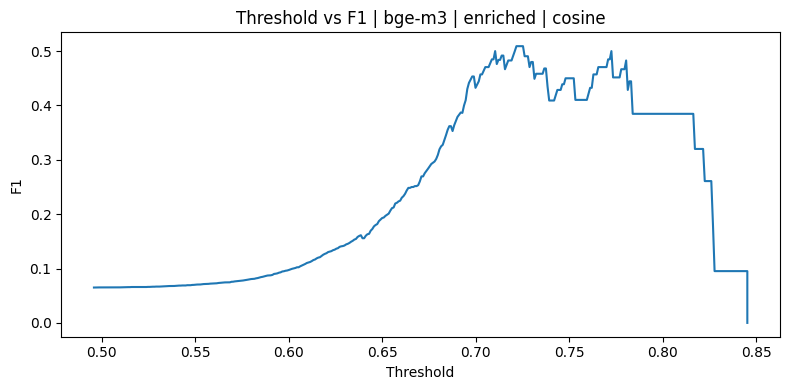

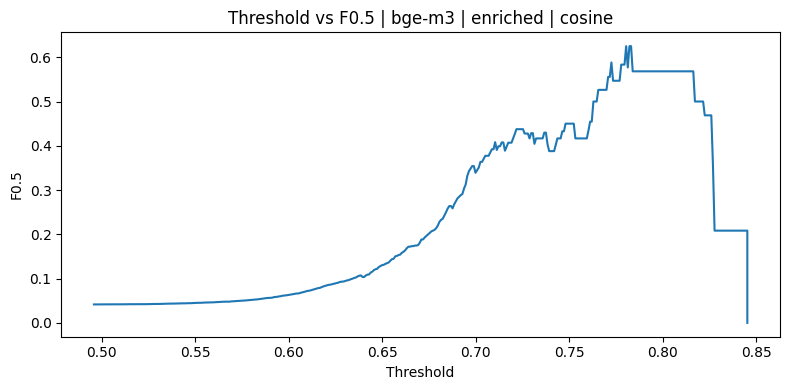

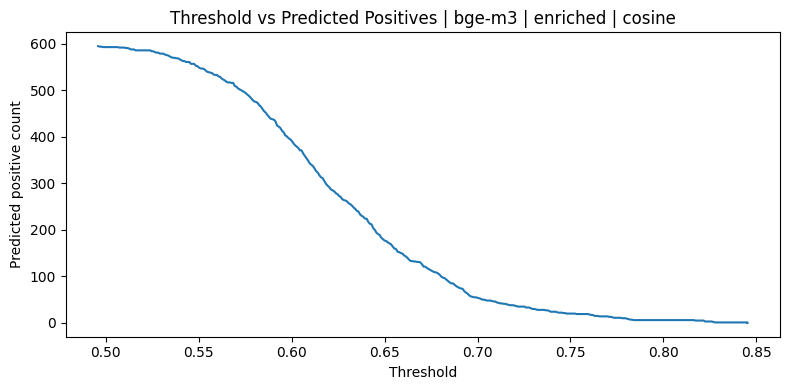

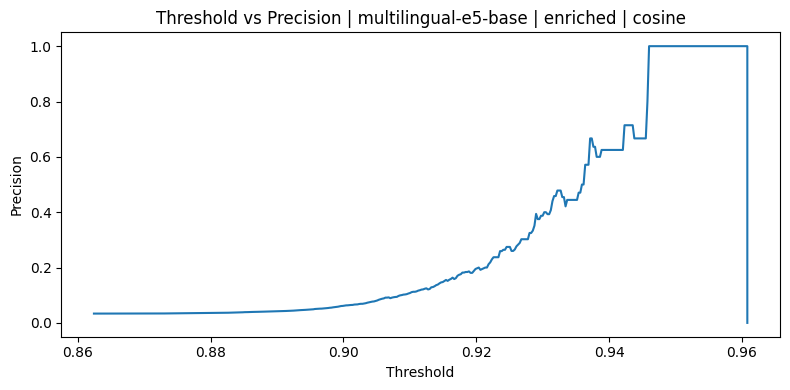

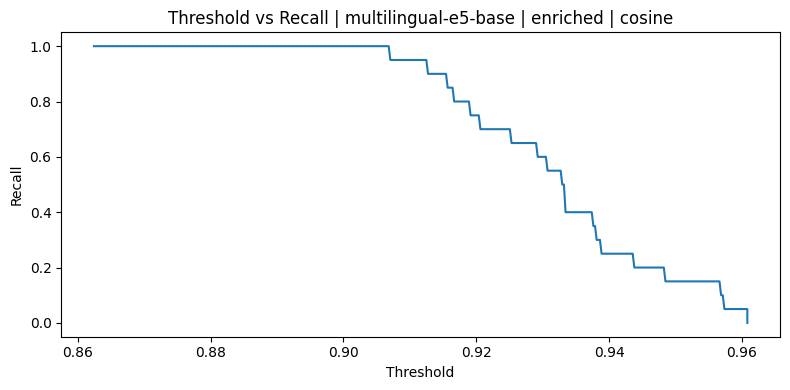

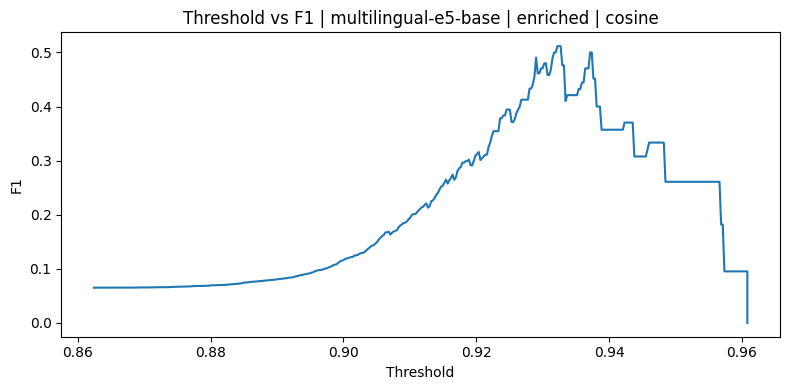

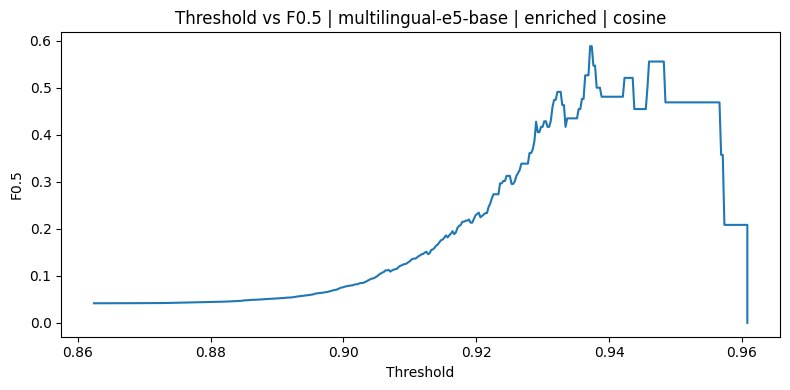

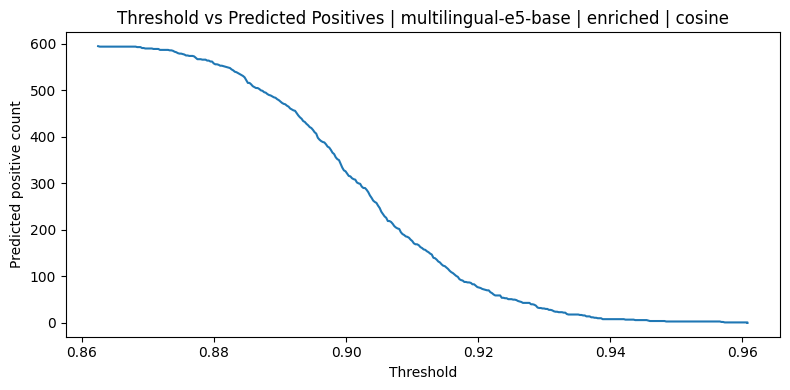

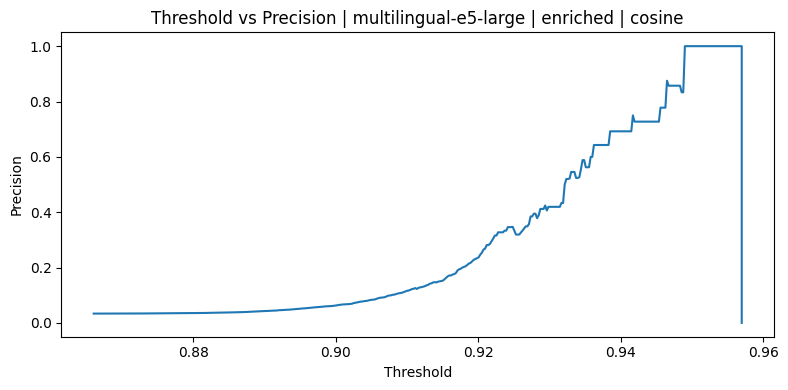

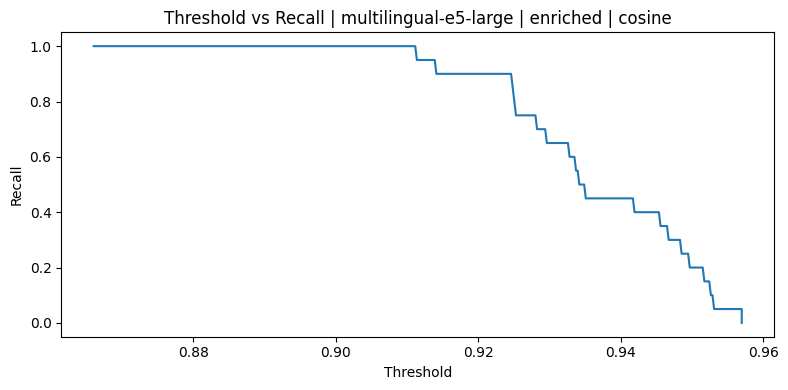

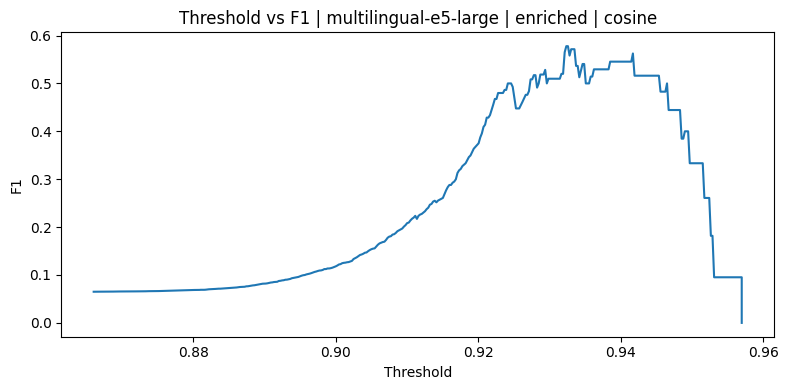

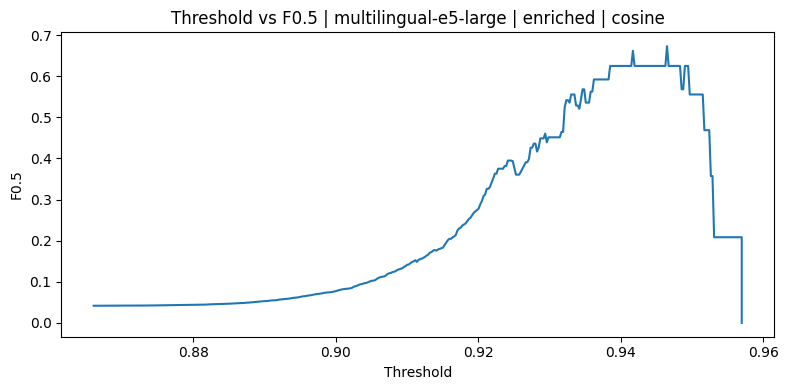

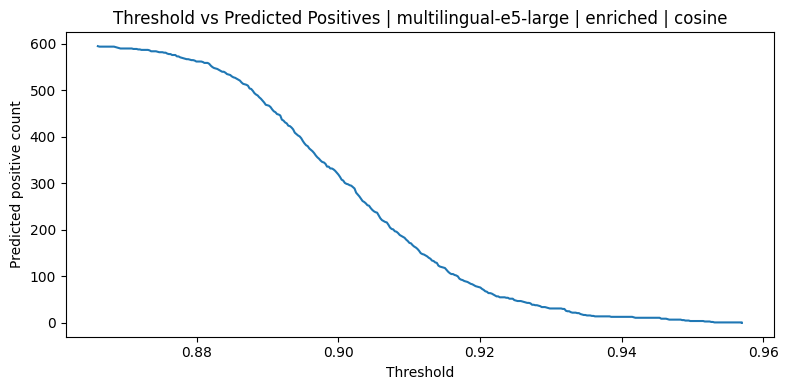

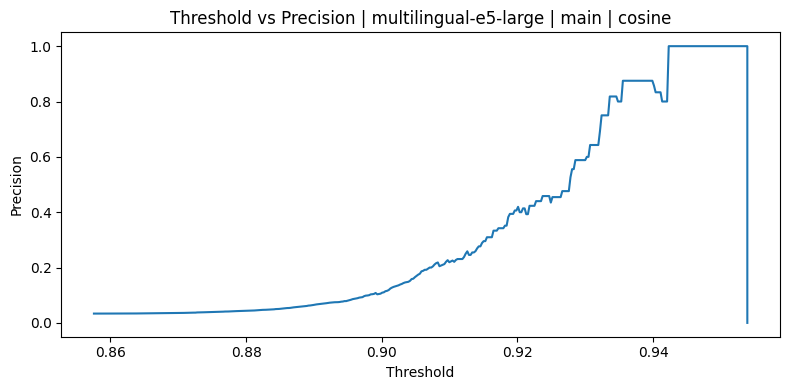

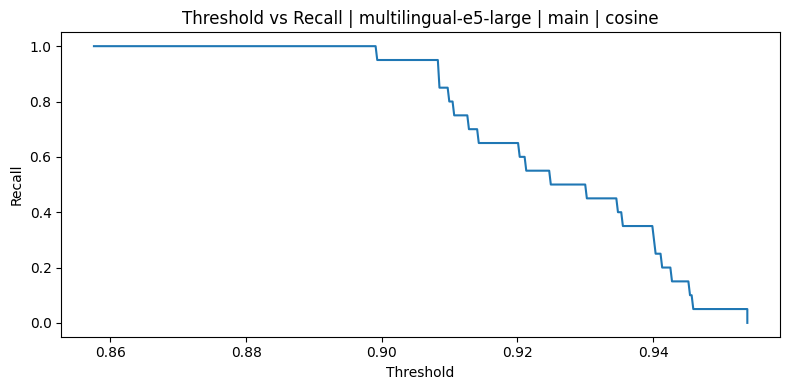

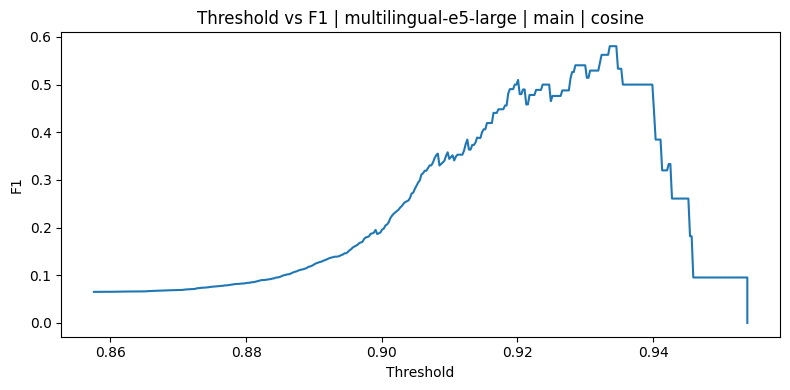

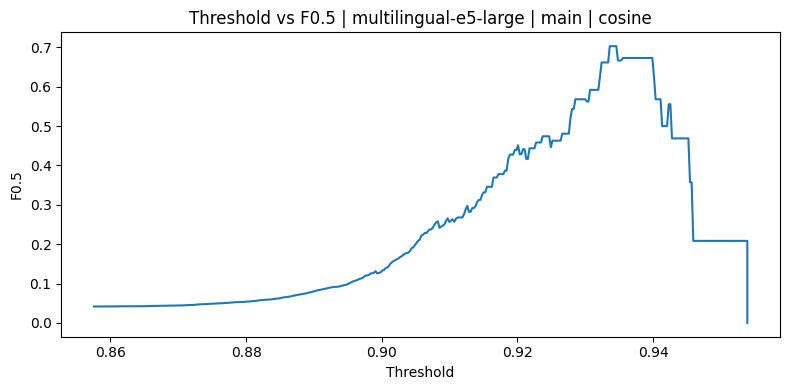

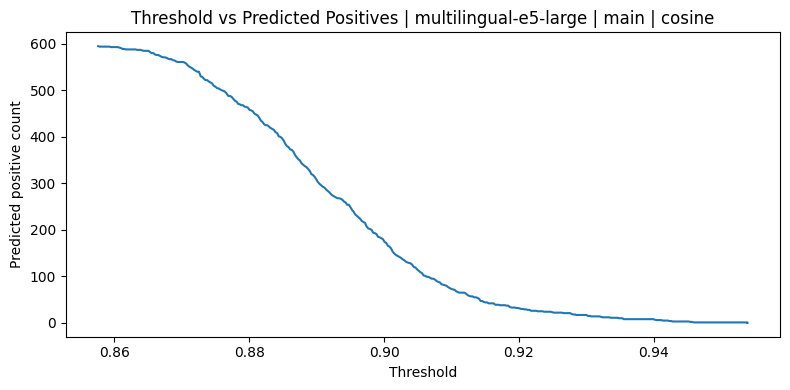

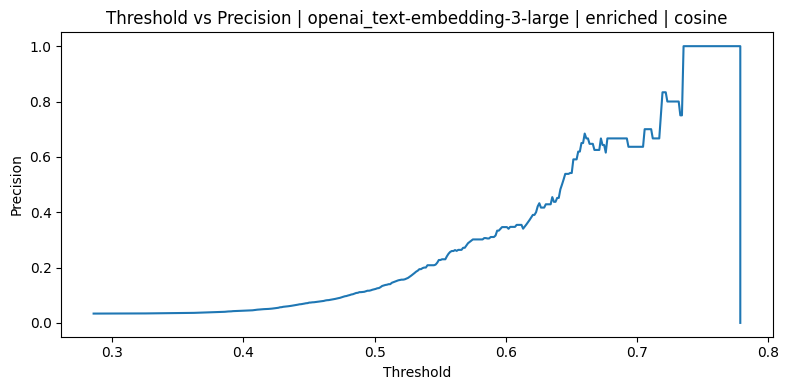

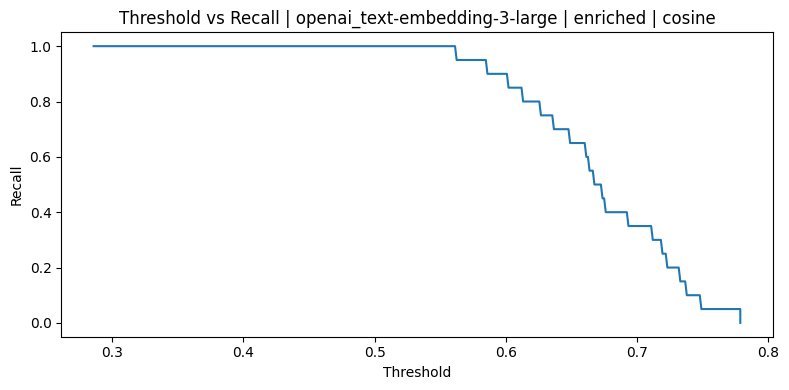

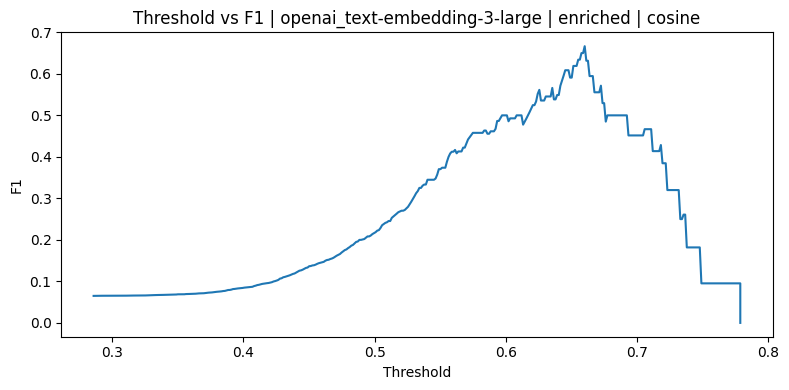

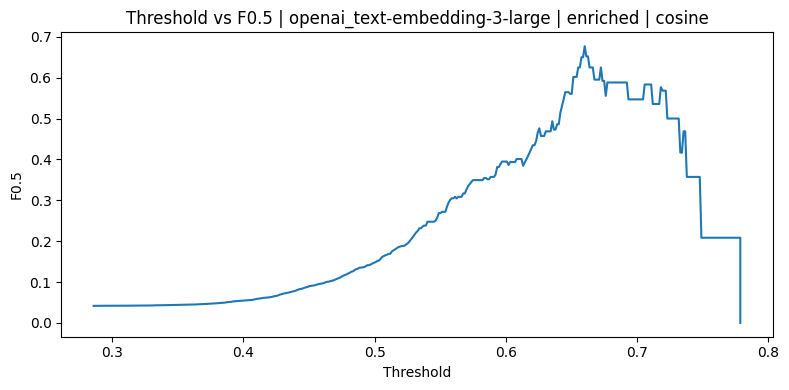

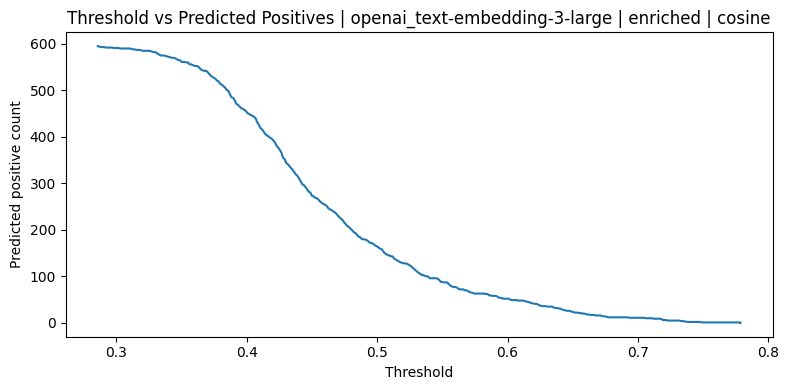

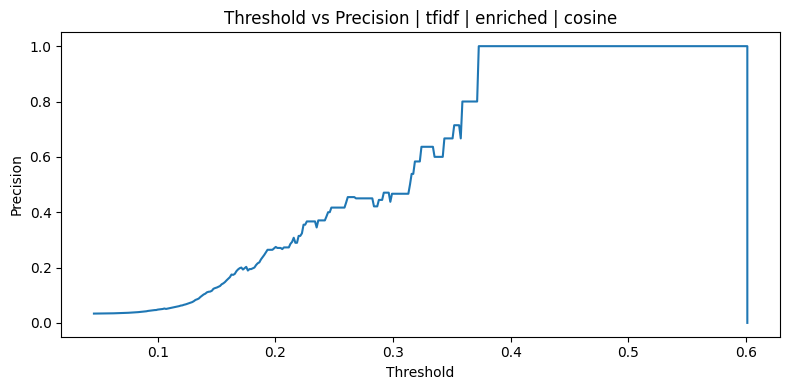

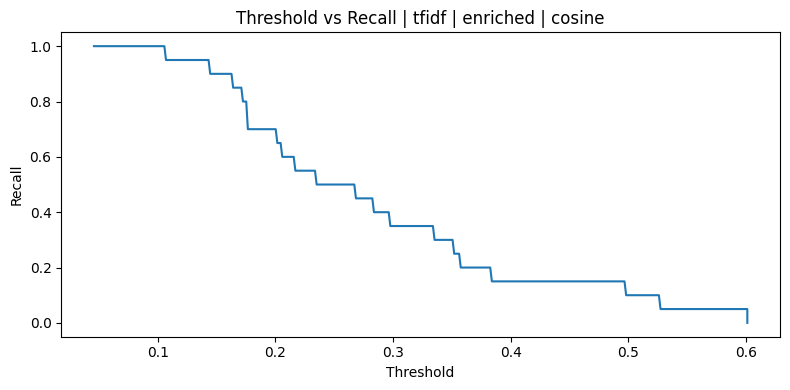

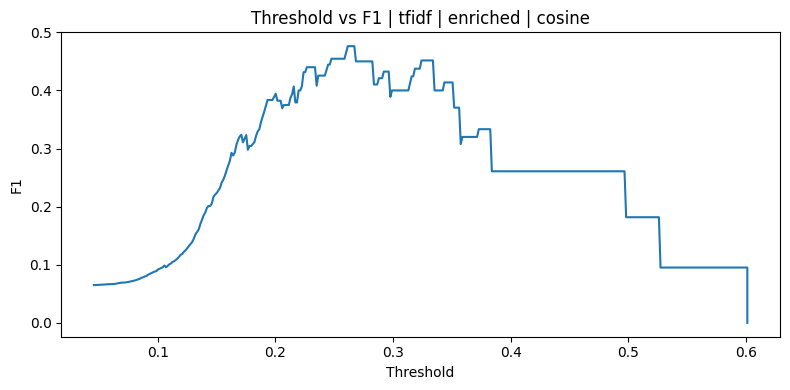

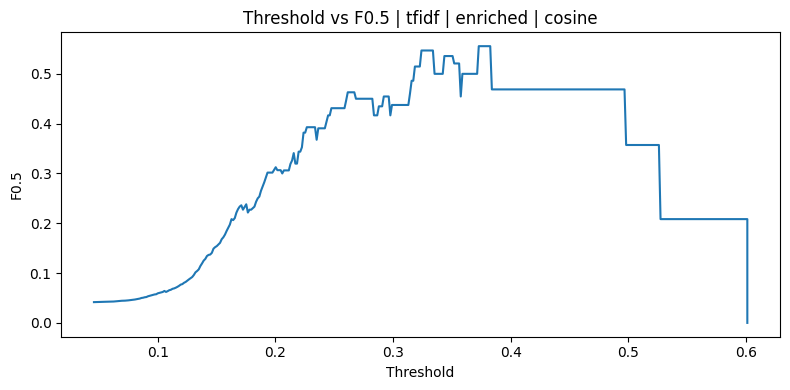

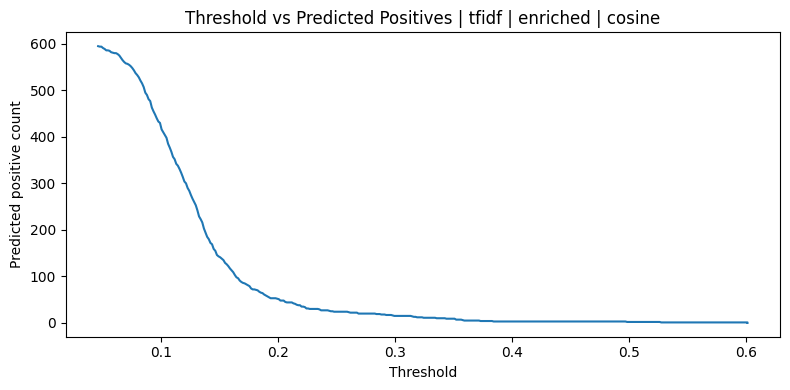

In [11]:
# Cell 11 - Plot threshold behavior for each shortlisted configuration

for (model_name, text_variant, similarity_metric), group_df in threshold_scan_dev_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    plot_df = group_df.sort_values("threshold").reset_index(drop=True)

    # Precision
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["precision"])
    plt.xlabel("Threshold")
    plt.ylabel("Precision")
    plt.title(f"Threshold vs Precision | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"threshold_precision_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

    # Recall
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["recall"])
    plt.xlabel("Threshold")
    plt.ylabel("Recall")
    plt.title(f"Threshold vs Recall | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"threshold_recall_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

    # F1
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f1"])
    plt.xlabel("Threshold")
    plt.ylabel("F1")
    plt.title(f"Threshold vs F1 | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"threshold_f1_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

    # F0.5
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f05"])
    plt.xlabel("Threshold")
    plt.ylabel("F0.5")
    plt.title(f"Threshold vs F0.5 | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"threshold_f05_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

    # Predicted positives
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["predicted_positive_count"])
    plt.xlabel("Threshold")
    plt.ylabel("Predicted positive count")
    plt.title(f"Threshold vs Predicted Positives | {model_name} | {text_variant} | {similarity_metric}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"threshold_predicted_positive_count_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

### Lock one threshold per shortlisted configuration

The development-set candidate thresholds are now converted into one **locked threshold** per configuration.

Selection principle:

- prefer **max_f1** when it gives a strong balance and reviewer load is still reasonable
- prefer **max_f05** when precision control is more important and max-F1 is too permissive
- prefer **reviewer_load_target_10** when max-F1 is clearly too reviewer-heavy but precision-floor is too conservative
- use **precision_floor_080** only when a configuration remains too permissive under the other strategies

These locked thresholds are selected on the **development split only** and then applied unchanged to the **test split**.

In [12]:
# Cell 12 - Build a threshold selection support table

selection_support_df = candidate_thresholds_dev_df.copy()

selection_support_df["reviewer_load_reasonable"] = selection_support_df["predicted_positive_count"].between(6, 20)
selection_support_df["precision_strong"] = selection_support_df["precision"] >= 0.70
selection_support_df["recall_minimum_ok"] = selection_support_df["recall"] >= 0.30

selection_support_df = selection_support_df.sort_values(
    ["model_name", "text_variant", "similarity_metric", "selection_rule"]
).reset_index(drop=True)

display(selection_support_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "predicted_positive_count",
    "reviewer_load_reasonable",
    "precision_strong",
    "recall_minimum_ok",
]])

,model_name,text_variant,similarity_metric,selection_rule,threshold,precision,recall,f1,f05,predicted_positive_count,reviewer_load_reasonable,precision_strong,recall_minimum_ok
0,bge-m3,enriched,cosine,max_f05,0.782218,0.857143,0.30,0.444444,0.625000,7,True,True,True
1,bge-m3,enriched,cosine,max_f1,0.721789,0.400000,0.70,0.509091,0.437500,35,False,False,True
2,bge-m3,enriched,cosine,precision_floor_080,0.782218,0.857143,0.30,0.444444,0.625000,7,True,True,True
3,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,10,True,True,True
4,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,12,True,False,True
5,multilingual-e5-base,enriched,cosine,max_f1,0.932211,0.478261,0.55,0.511628,0.491071,23,False,False,True
6,multilingual-e5-base,enriched,cosine,precision_floor_080,0.946016,1.000000,0.20,0.333333,0.555556,4,False,True,False
7,multilingual-e5-base,enriched,cosine,reviewer_load_target_10,0.938127,0.600000,0.30,0.400000,0.500000,10,True,False,True
8,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,8,True,True,True
9,multilingual-e5-large,enriched,cosine,max_f1,0.932374,0.520000,0.65,0.577778,0.541667,25,False,False,True


In [ ]:
# Cell 13 - Select one locked threshold per shortlisted configuration using explicit rules

LOCKED_THRESHOLD_RULES = {
    ("openai_text-embedding-3-large", "enriched", "cosine"): "max_f1",  # Best overall shortlist winner with the clearest precision–recall balance on dev.
    ("multilingual-e5-large", "enriched", "cosine"): "max_f05",         # Strong ranking quality, but a more precision-oriented threshold is preferred to control false positives.
    ("multilingual-e5-large", "main", "cosine"): "max_f1",              # Balanced dev-time threshold is sufficient for the simpler main-text variant.
    ("bge-m3", "enriched", "cosine"): "reviewer_load_target_10",        # Practical cap used because this configuration becomes less useful when reviewer load grows too high.
    ("multilingual-e5-base", "enriched", "cosine"): "max_f05",          # Slightly more conservative threshold rule chosen to favor precision over recall.
    ("tfidf", "enriched", "cosine"): "reviewer_load_target_10",         # Baseline included for comparison, but constrained with a practical reviewer-load target.
}

selected_threshold_rows = []

for (model_name, text_variant, similarity_metric), selection_rule in LOCKED_THRESHOLD_RULES.items():
    match_df = candidate_thresholds_dev_df[
        (candidate_thresholds_dev_df["model_name"] == model_name) &
        (candidate_thresholds_dev_df["text_variant"] == text_variant) &
        (candidate_thresholds_dev_df["similarity_metric"] == similarity_metric) &
        (candidate_thresholds_dev_df["selection_rule"] == selection_rule)
    ].copy()

    if match_df.empty:
        raise ValueError(
            f"No candidate threshold found for model={model_name}, text_variant={text_variant}, "
            f"similarity_metric={similarity_metric}, selection_rule={selection_rule}."
        )

    selected_row = match_df.iloc[0].to_dict()
    selected_threshold_rows.append(selected_row)

selected_thresholds_df = pd.DataFrame(selected_threshold_rows)

selected_thresholds_df = selected_thresholds_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "threshold",
    "precision",
    "recall",
    "f1",
    "f05",
    "accuracy",
    "specificity",
    "predicted_positive_count",
    "tp",
    "fp",
    "fn",
    "tn",
]].copy()

selected_thresholds_df = selected_thresholds_df.sort_values(
    ["f1", "f05", "precision", "recall"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

selected_thresholds_df.to_csv(SELECTED_THRESHOLDS_CSV_PATH, index=False, encoding="utf-8")

print("Saved selected thresholds to:", SELECTED_THRESHOLDS_CSV_PATH)
display(selected_thresholds_df)

Saved selected thresholds to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\selected_thresholds_for_test.csv


,model_name,text_variant,similarity_metric,selection_rule,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tp,fp,fn,tn
0,openai_text-embedding-3-large,enriched,cosine,max_f1,0.660026,0.684211,0.65,0.666667,0.677083,0.978151,0.989565,19,13,6,7,569
1,multilingual-e5-large,main,cosine,max_f1,0.933620,0.818182,0.45,0.580645,0.703125,0.978151,0.996522,11,9,2,11,573
2,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,0.976471,0.998261,8,7,1,13,574
3,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,0.973109,0.993043,12,8,4,12,571
4,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,0.973109,0.994783,10,7,3,13,572
5,tfidf,enriched,cosine,reviewer_load_target_10,0.335330,0.600000,0.30,0.400000,0.500000,0.969748,0.993043,10,6,4,14,571


### Evaluate locked thresholds on the test split

The selected thresholds are now applied to the **test split only**.

Important:
- the test set was **not** used to choose these thresholds
- test metrics are therefore a held-out evaluation
- because the test set contains only **5 positive pairs**, results must be interpreted cautiously

In [14]:
# Cell 14 - Evaluate locked thresholds on the test split

test_scores_df = evaluation_scores_df[evaluation_scores_df["split"] == "test"].copy()

if test_scores_df.empty:
    raise ValueError("Test split is empty after shortlist filtering.")

test_evaluation_rows = []

for _, threshold_row in selected_thresholds_df.iterrows():
    model_name = threshold_row["model_name"]
    text_variant = threshold_row["text_variant"]
    similarity_metric = threshold_row["similarity_metric"]
    locked_threshold = float(threshold_row["threshold"])

    group_df = test_scores_df[
        (test_scores_df["model_name"] == model_name) &
        (test_scores_df["text_variant"] == text_variant) &
        (test_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    if group_df.empty:
        raise ValueError(
            f"No test rows found for model={model_name}, text_variant={text_variant}, similarity_metric={similarity_metric}."
        )

    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    metrics = compute_threshold_metrics(y_true=y_true, y_score=y_score, threshold=locked_threshold)

    test_evaluation_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "selection_rule": threshold_row["selection_rule"],
        "locked_threshold": locked_threshold,
        "pair_count_test": len(group_df),
        "positive_count_test": int(group_df["overlap_label_binary"].sum()),
        **metrics,
    })

test_evaluation_df = pd.DataFrame(test_evaluation_rows)
test_evaluation_df.to_csv(TEST_EVALUATION_CSV_PATH, index=False, encoding="utf-8")

print("Saved test evaluation table to:", TEST_EVALUATION_CSV_PATH)
display(test_evaluation_df)

Saved test evaluation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\test_evaluation_locked_thresholds.csv


,model_name,text_variant,similarity_metric,selection_rule,locked_threshold,pair_count_test,positive_count_test,threshold,precision,recall,f1,f05,accuracy,specificity,predicted_positive_count,tn,fp,fn,tp
0,openai_text-embedding-3-large,enriched,cosine,max_f1,0.660026,105,5,0.660026,0.800000,0.8,0.800000,0.800000,0.980952,0.99,5,99,1,1,4
1,multilingual-e5-large,main,cosine,max_f1,0.933620,105,5,0.933620,0.600000,0.6,0.600000,0.600000,0.961905,0.98,5,98,2,2,3
2,multilingual-e5-large,enriched,cosine,max_f05,0.946509,105,5,0.946509,1.000000,0.6,0.750000,0.882353,0.980952,1.00,3,100,0,2,3
3,multilingual-e5-base,enriched,cosine,max_f05,0.937141,105,5,0.937141,0.666667,0.8,0.727273,0.689655,0.971429,0.98,6,98,2,1,4
4,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,105,5,0.777839,0.750000,0.6,0.666667,0.714286,0.971429,0.99,4,99,1,2,3
5,tfidf,enriched,cosine,reviewer_load_target_10,0.335330,105,5,0.335330,0.333333,1.0,0.500000,0.384615,0.904762,0.90,15,90,10,0,5


### Compare development and test stability

This comparison shows how each locked threshold behaves from development to test.

The goal is not only to find the highest development F1, but to see:

- which thresholds generalize best
- which thresholds become unstable on test
- which models remain practically usable under held-out evaluation

In [15]:
# Cell 15 - Compare dev and test metrics for the locked thresholds

dev_locked_df = selected_thresholds_df.rename(columns={
    "threshold": "dev_locked_threshold",
    "precision": "dev_precision",
    "recall": "dev_recall",
    "f1": "dev_f1",
    "f05": "dev_f05",
    "accuracy": "dev_accuracy",
    "specificity": "dev_specificity",
    "predicted_positive_count": "dev_predicted_positive_count",
    "tp": "dev_tp",
    "fp": "dev_fp",
    "fn": "dev_fn",
    "tn": "dev_tn",
})

test_locked_df = test_evaluation_df.rename(columns={
    "precision": "test_precision",
    "recall": "test_recall",
    "f1": "test_f1",
    "f05": "test_f05",
    "accuracy": "test_accuracy",
    "specificity": "test_specificity",
    "predicted_positive_count": "test_predicted_positive_count",
    "tp": "test_tp",
    "fp": "test_fp",
    "fn": "test_fn",
    "tn": "test_tn",
})

dev_test_comparison_df = dev_locked_df.merge(
    test_locked_df,
    on=["model_name", "text_variant", "similarity_metric", "selection_rule"],
    how="inner"
)

dev_test_comparison_df["precision_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_precision"] - dev_test_comparison_df["dev_precision"]
)
dev_test_comparison_df["recall_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_recall"] - dev_test_comparison_df["dev_recall"]
)
dev_test_comparison_df["f1_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_f1"] - dev_test_comparison_df["dev_f1"]
)
dev_test_comparison_df["f05_delta_test_minus_dev"] = (
    dev_test_comparison_df["test_f05"] - dev_test_comparison_df["dev_f05"]
)

dev_test_comparison_df.to_csv(DEV_TEST_COMPARISON_CSV_PATH, index=False, encoding="utf-8")

print("Saved dev/test threshold comparison to:", DEV_TEST_COMPARISON_CSV_PATH)

display(dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_f05",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "precision_delta_test_minus_dev",
    "recall_delta_test_minus_dev",
    "f1_delta_test_minus_dev",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]])

Saved dev/test threshold comparison to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\dev_test_threshold_comparison.csv


,model_name,text_variant,similarity_metric,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_f05,test_precision,test_recall,test_f1,test_f05,precision_delta_test_minus_dev,recall_delta_test_minus_dev,f1_delta_test_minus_dev,dev_predicted_positive_count,test_predicted_positive_count
0,openai_text-embedding-3-large,enriched,cosine,max_f1,0.660026,0.684211,0.65,0.666667,0.677083,0.800000,0.8,0.800000,0.800000,0.115789,0.15,0.133333,19,5
1,multilingual-e5-large,main,cosine,max_f1,0.933620,0.818182,0.45,0.580645,0.703125,0.600000,0.6,0.600000,0.600000,-0.218182,0.15,0.019355,11,5
2,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,1.000000,0.6,0.750000,0.882353,0.125000,0.25,0.250000,8,3
3,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,0.666667,0.8,0.727273,0.689655,0.000000,0.40,0.227273,12,6
4,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,0.750000,0.6,0.666667,0.714286,0.050000,0.25,0.200000,10,4
5,tfidf,enriched,cosine,reviewer_load_target_10,0.335330,0.600000,0.30,0.400000,0.500000,0.333333,1.0,0.500000,0.384615,-0.266667,0.70,0.100000,10,15


### Practical interpretation for the PoC

A good threshold is not only one that scores well mathematically.

It should also be practical for a curriculum reviewer:

- predicted positive count should be manageable
- false positives should not dominate the review load
- threshold behavior should be reasonably stable
- the reported overlaps should be interpretable enough to support the later UI

In [16]:
# Cell 16 - Practical threshold interpretation table

practical_interpretation_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_f05",
    "dev_predicted_positive_count",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "test_predicted_positive_count",
    "test_fp",
    "test_fn",
    "test_tp",
]].copy()

practical_interpretation_df = practical_interpretation_df.sort_values(
    ["test_f1", "test_f05", "test_precision", "dev_f1"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

practical_interpretation_df.to_csv(PRACTICAL_INTERPRETATION_CSV_PATH, index=False, encoding="utf-8")

print("Saved practical interpretation table to:", PRACTICAL_INTERPRETATION_CSV_PATH)
display(practical_interpretation_df)

Saved practical interpretation table to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\thresholds\practical_threshold_interpretation.csv


,model_name,text_variant,similarity_metric,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_f05,dev_predicted_positive_count,test_precision,test_recall,test_f1,test_f05,test_predicted_positive_count,test_fp,test_fn,test_tp
0,openai_text-embedding-3-large,enriched,cosine,max_f1,0.660026,0.684211,0.65,0.666667,0.677083,19,0.800000,0.8,0.800000,0.800000,5,1,1,4
1,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,8,1.000000,0.6,0.750000,0.882353,3,0,2,3
2,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,12,0.666667,0.8,0.727273,0.689655,6,2,1,4
3,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,10,0.750000,0.6,0.666667,0.714286,4,1,2,3
4,multilingual-e5-large,main,cosine,max_f1,0.933620,0.818182,0.45,0.580645,0.703125,11,0.600000,0.6,0.600000,0.600000,5,2,2,3
5,tfidf,enriched,cosine,reviewer_load_target_10,0.335330,0.600000,0.30,0.400000,0.500000,10,0.333333,1.0,0.500000,0.384615,15,10,0,5


### Final threshold winner decision

The final winner should not be chosen using development AP alone.

It should combine:

- Notebook 03 ranking quality
- Notebook 04 threshold behavior on development
- held-out test behavior
- practical reviewer usability

Because the test set contains only 5 positives, the result should be interpreted as a **careful PoC recommendation**, not as a final production guarantee.

In [18]:
# Cell 17 - Final threshold winner summary with balanced thesis interpretation

final_ranking_df = dev_test_comparison_df[[
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "dev_locked_threshold",
    "dev_precision",
    "dev_recall",
    "dev_f1",
    "dev_f05",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f05",
    "dev_predicted_positive_count",
    "test_predicted_positive_count",
]].copy()

final_ranking_df = final_ranking_df.sort_values(
    ["test_f1", "test_f05", "test_precision", "dev_f1"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

display(final_ranking_df)

best_row = final_ranking_df.iloc[0]

print("Final thesis-oriented interpretation:")
print()
print("Primary recommendation:")
print(f"  {best_row['model_name']} + {best_row['text_variant']} + {best_row['similarity_metric']}")
print("  Reason: strongest overall combination of development-set ranking quality,")
print("  development-set threshold behavior, held-out test performance,")
print("  and practical reviewer workload under this small-data PoC setting.")
print()

print("Important interpretation notes:")
print("  - Test results are informative but unstable because the test split has only 5 positives.")
print("  - Notebook 03 ranking quality still matters and should not be overridden by one small test split.")
print("  - Threshold choice should therefore be interpreted as a careful PoC operating point,")
print("    not a final production guarantee.")
print()

print("Alternative configuration insight:")
print("  - A strong alternative was multilingual-e5-large with the enriched representation,")
print("    which achieved perfect test precision at lower recall, making it attractive")
print("    for more conservative overlap flagging scenarios.")
print()

print("Recommended PoC deployment logic:")
print(f"  Use {best_row['model_name']} + {best_row['text_variant']} + {best_row['similarity_metric']}")
print(f"  with locked threshold {best_row['dev_locked_threshold']:.6f}")

,model_name,text_variant,similarity_metric,selection_rule,dev_locked_threshold,dev_precision,dev_recall,dev_f1,dev_f05,test_precision,test_recall,test_f1,test_f05,dev_predicted_positive_count,test_predicted_positive_count
0,openai_text-embedding-3-large,enriched,cosine,max_f1,0.660026,0.684211,0.65,0.666667,0.677083,0.800000,0.8,0.800000,0.800000,19,5
1,multilingual-e5-large,enriched,cosine,max_f05,0.946509,0.875000,0.35,0.500000,0.673077,1.000000,0.6,0.750000,0.882353,8,3
2,multilingual-e5-base,enriched,cosine,max_f05,0.937141,0.666667,0.40,0.500000,0.588235,0.666667,0.8,0.727273,0.689655,12,6
3,bge-m3,enriched,cosine,reviewer_load_target_10,0.777839,0.700000,0.35,0.466667,0.583333,0.750000,0.6,0.666667,0.714286,10,4
4,multilingual-e5-large,main,cosine,max_f1,0.933620,0.818182,0.45,0.580645,0.703125,0.600000,0.6,0.600000,0.600000,11,5
5,tfidf,enriched,cosine,reviewer_load_target_10,0.335330,0.600000,0.30,0.400000,0.500000,0.333333,1.0,0.500000,0.384615,10,15


Final thesis-oriented interpretation:

Primary recommendation:
  openai_text-embedding-3-large + enriched + cosine
  Reason: strongest overall combination of development-set ranking quality,
  development-set threshold behavior, held-out test performance,
  and practical reviewer workload under this small-data PoC setting.

Important interpretation notes:
  - Test results are informative but unstable because the test split has only 5 positives.
  - Notebook 03 ranking quality still matters and should not be overridden by one small test split.
  - Threshold choice should therefore be interpreted as a careful PoC operating point,
    not a final production guarantee.

Alternative configuration insight:
  - A strong alternative was multilingual-e5-large with the enriched representation,
    which achieved perfect test precision at lower recall, making it attractive
    for more conservative overlap flagging scenarios.

Recommended PoC deployment logic:
  Use openai_text-embedding-3-large 

## Final note

Notebook 04 turns similarity scores into thresholded overlap decisions for the shortlisted configurations identified in Notebook 03.

### What this notebook does well
- selects thresholds using development data only
- preserves a held-out test evaluation
- compares multiple threshold strategies
- highlights practical tradeoffs between precision, recall, and reviewer load
- connects benchmark ranking quality to real overlap-flagging behavior

### Methodological clarification
Dense-model cosine and dot similarity behaved nearly identically in Notebook 03 due to almost constant embedding norms across samples. For interpretability and simplicity, Notebook 04 therefore carries forward cosine similarity only.

### Important limitations
- the test split contains only 5 positive pairs
- small changes in threshold behavior may therefore change test metrics noticeably
- results should be interpreted as strong PoC evidence rather than final production-grade calibration

Together, Notebook 03 and Notebook 04 provide a defensible answer to the thesis question of which model and threshold combination best balances precision and recall for curriculum overlap detection.